In [2]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
import json

# Loading

Real-Data-2 pre-processed data

Convert to anndata for new package analysis

In [162]:
# load counts
data_FIB = pd.read_csv("../../Moment-equations/Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta = np.loadtxt("../../Moment-equations/Real-Data-2/Capture/beta_FIB.txt")

# load RNA types
biotypes_dict = json.load(open("../../Moment-equations/Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# select protein coding genes
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]

# select miRNA
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]

In [163]:
# convert to anndata: transpose to cell x gene convention
adata_miRNA = ad.AnnData(data_FIB_miRNA.T)
adata_pcRNA = ad.AnnData(data_FIB_pcRNA.T)

# miRNA Distributions

See actually higher miRNA levels for all, no need for additional selection

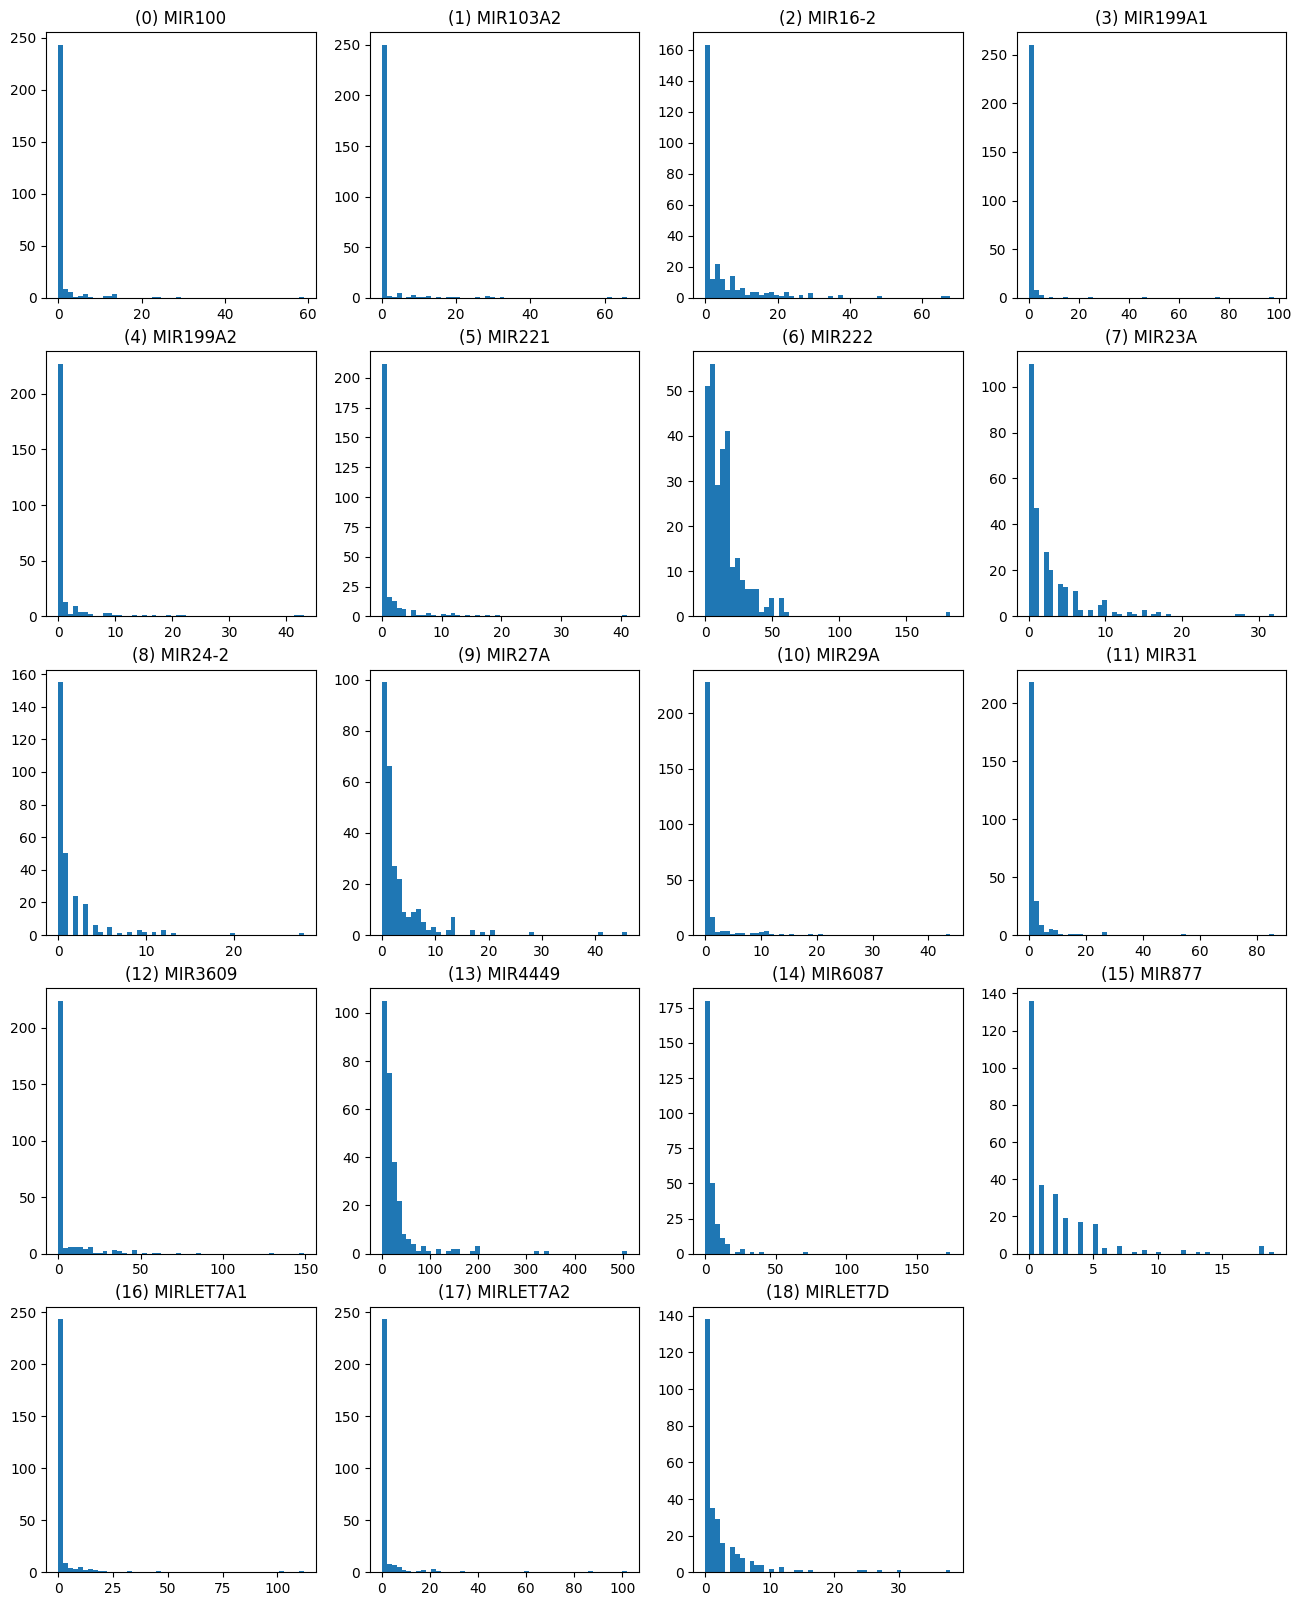

In [164]:
# miRNA distributions
M, N = 5, 4
fig, axs = plt.subplots(M, N, figsize=(N * 4, M * 4))
k = 0
for i in range(M):
    for j in range(N):
        if k == 19:
            axs[i, j].axis('off')
            break
        data = adata_miRNA[:, k]
        sample = data.X.toarray()
        axs[i, j].hist(sample, bins=50)
        axs[i, j].set_title(f"({k}) {data.var.iloc[0].name}")
        k += 1
plt.show()

In [165]:
# max observed count per miRNA
max_count = adata_miRNA.X.max(axis=0)

# select
count_mask = (max_count >= 3).squeeze()
miRNA_idxs = np.arange(len(count_mask))[count_mask]

# subset miRNA
adata_miRNA = adata_miRNA[:, miRNA_idxs]

# display
print(f"{sum(count_mask)} / {len(count_mask)} miRNA retained")

19 / 19 miRNA retained


# Model Free

In [ ]:
# settings
d = 4

# get pcRNA names
pcRNA_names = adata_pcRNA.var.index.tolist()

# initialize result dataframes
#MF_ind_df = pd.DataFrame(index=pcRNA_names)
#MF_int_df = pd.DataFrame(index=pcRNA_names)
#corr_df = pd.DataFrame(index=pcRNA_names)

miRNA_indices = [6, 7, 15]
 
# for each miRNA
for i in miRNA_indices: # range(adata_miRNA.n_vars):

    # manual selection
    #i = 6

    # select miRNA
    miRNA = adata_miRNA[:, i].var.iloc[0].name

    # display progress
    print(f"{i + 1} / {adata_miRNA.n_vars}: {miRNA}")

    # initialize dataset -------------------------------------------------------
    data = SDP_miRNA.dataset.Dataset()

    # construct dataset with default: miRNA paired with all mRNA
    data.construct_dataset_adata(
        adata_miRNA[:, i],
        adata_pcRNA,
        beta
    )

    # bootstrap
    data.bootstrap(d=d)

    # OB & AL estimates: point and interval ------------------------------------
    OB_corrs, AL_corrs = SDP_miRNA.correlation.compute_correlations(data)

    # store
    corr_df[f'{miRNA}_OB'] = OB_corrs[:, 0]
    corr_df[f'{miRNA}_OB_min'] = OB_corrs[:, 1]
    corr_df[f'{miRNA}_OB_max'] = OB_corrs[:, 2]
    corr_df[f'{miRNA}_AL'] = AL_corrs[:, 0]
    corr_df[f'{miRNA}_AL_min'] = AL_corrs[:, 1]
    corr_df[f'{miRNA}_AL_max'] = AL_corrs[:, 2]

    # model free independence test ---------------------------------------------
    MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(data, d=d)
    MF_ind.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in MF_ind.result_dict.values()])

    # store
    MF_ind_df[f'{miRNA}_status'] = status

    # select indices of interacting pairs --------------------------------------
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

    # reduce gene queries to these
    gene_queries = [
        [[0], [int(i)]] for i in int_idxs
    ]

    # store previous total
    full_query_total = data.total_gene_queries

    # reduce dataset
    data.gene_queries = gene_queries
    data.total_gene_queries = len(gene_queries)
    data.moment_bounds = data.moment_bounds[:, int_idxs, :]

    # model free interacting test (including Hit & Run)
    MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data, d=d)
    MF_int.analyse_dataset()

    # Hit & Run correlations
    HAR_points, HAR_intervals = MF_int.compute_dataset_correlation()

    # Hit & Run midpoint: useful statistic
    HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

    # embedd MF int results (only on interacting pairs) into array of all pairs
    HAR_all = np.empty((full_query_total, 3)) * np.nan
    HAR_all[int_idxs, 0] = HAR_intervals[:, 0]
    HAR_all[int_idxs, 1] = HAR_intervals[:, 1]
    HAR_all[int_idxs, 2] = HAR_mid

    # store
    MF_int_df[f'{miRNA}_HAR_min'] = HAR_all[:, 0]
    MF_int_df[f'{miRNA}_HAR_max'] = HAR_all[:, 1]
    MF_int_df[f'{miRNA}_HAR_mid'] = HAR_all[:, 2]

    # write results ------------------------------------------------------------
    #MF_ind_df.to_csv(f"Results/d4/independent_MF.csv") # commented out after running
    #MF_int_df.to_csv(f"Results/d4/interacting_MF.csv")
    #corr_df.to_csv(f"Results/d4/correlation.csv")

7 / 19: MIR222


  1%|          | 5/611 [00:06<12:34,  1.24s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range
Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range
Optimization failed: list index out of range


  3%|▎         | 16/611 [00:18<12:11,  1.23s/it]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 105, in analyse_dataset
    feasible_points_HAR, t_int_err, t_int_eps = self.hit_and_run(i, feasible_points[0])
IndexError: list index out of range


Optimization failed: list index out of range


...

 91%|█████████ | 1015/1120 [00:22<00:02, 41.41it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 91%|█████████ | 1021/1120 [00:22<00:02, 43.70it/s]

Computation failed: 'NoneType' object is not iterable


 92%|█████████▏| 1026/1120 [00:22<00:02, 43.08it/s]Traceback (most recent call last):
  File "c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\SDP_miRNA\optimization_MOSEK.py", line 395, in compute_dataset_correlation
    correlation_list = [
TypeError: 'NoneType' object is not iterable
 92%|█████████▏| 1031/1120 [00:23<00:02, 43.64it/s]

Computation failed: 'NoneType' object is not iterable


100%|██████████| 1120/1120 [00:25<00:00, 44.56it/s]


In [ ]:
# d = 3: 280min

1 / 19: MIR100


100%|██████████| 983/983 [00:21<00:00, 44.87it/s]


2 / 19: MIR103A2


100%|██████████| 1810/1810 [00:37<00:00, 48.53it/s]


3 / 19: MIR16-2


...

100%|██████████| 93/93 [00:04<00:00, 22.91it/s]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_AL_min'] = AL_corrs[:, 1]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_AL_max'] = AL_corrs[:, 2]
100%|██████████| 1063/1063 [00:21<00:00, 49.23it/s]


18 / 19: MIRLET7A2


100%|██████████| 93/93 [00:04<00:00, 21.72it/s]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_OB'] = OB_corrs[:, 0]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_OB_min'] = OB_corrs[:, 1]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

19 / 19: MIRLET7D


100%|██████████| 93/93 [00:04<00:00, 23.04it/s]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_OB'] = OB_corrs[:, 0]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  corr_df[f'{miRNA}_OB_min'] = OB_corrs[:, 1]
C:\Users\willi\AppData\Local\Temp\ipykernel_22516\3100511929.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

## Results

In [173]:
MF_ind_df.columns

Index(['MIR222_status', 'MIR23A_status', 'MIR877_status'], dtype='object')

In [184]:
miRNA = "MIR877"
G = adata_pcRNA.n_vars
x = (MF_ind_df[f'{miRNA}_status'] == "INFEASIBLE").sum()
print(f"{miRNA} | {round(100 * x / G, 1)}%  | {x} / {G}")

MIR877 | 12.0%  | 1120 / 9296


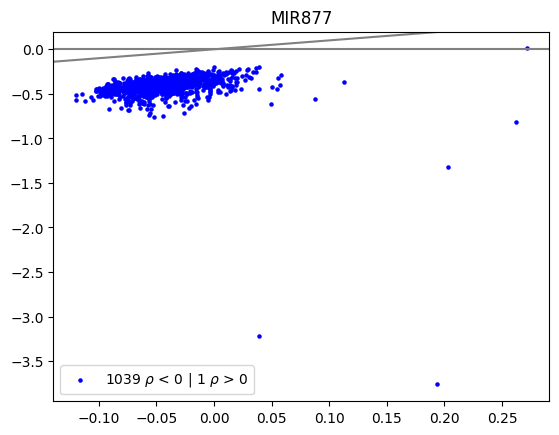

In [185]:
fig, axs = plt.subplots()

# interacting mask
mask = (MF_ind_df[f'{miRNA}_status'] == "INFEASIBLE").values.squeeze()

# HAR midpoint
mid = MF_int_df[f'{miRNA}_HAR_mid'][mask]

# OB
OB = corr_df[f'{miRNA}_OB'][mask]

# stats
x_neg = int((mid < 0).sum())
x_pos = int((mid > 0).sum())

# scatter
axs.scatter(OB, mid, color="blue", s=5, label=fr"{x_neg} $\rho$ < 0 | {x_pos} $\rho$ > 0")
#axs.set_ylim(bottom=-1, top=1)

# guide lines
m = np.mean(OB)
axs.axline([m]*2, [m+0.01]*2, color="grey")
axs.axhline(0, color="grey")

# text
axs.set_title(miRNA)
axs.legend()

plt.show()

## Comparison to previous results

In [32]:
MF_ind_df_old_1 = pd.read_csv("../../Moment-equations/Real-Data-2/Results/independent_MF.csv", index_col=0)
MF_ind_df_old_2 = pd.read_csv("../../Latent-Experiments/Cell-Cycle-Investigation/Results/independent_MF_concat.csv", index_col=0)

In [40]:
MF_ind_df.value_counts()

MIR222_status
OPTIMAL          9211
INFEASIBLE         85
Name: count, dtype: int64

In [35]:
MF_ind_df_old_1['MIR222_d3_c95_status'].value_counts()

MIR222_d3_c95_status
OPTIMAL       9217
INFEASIBLE      79
Name: count, dtype: int64

In [39]:
MF_ind_df_old_2['MIR222_All_d3_c95_status'].value_counts()

MIR222_All_d3_c95_status
OPTIMAL       9215
INFEASIBLE      81
Name: count, dtype: int64

In [41]:
MF_int_df_old_1 = pd.read_csv("../../Moment-equations/Real-Data-2/Results/interacting_MF.csv", index_col=0)
MF_int_df_old_2 = pd.read_csv("../../Latent-Experiments/Cell-Cycle-Investigation/Results/interacting_MF_concat.csv", index_col=0)

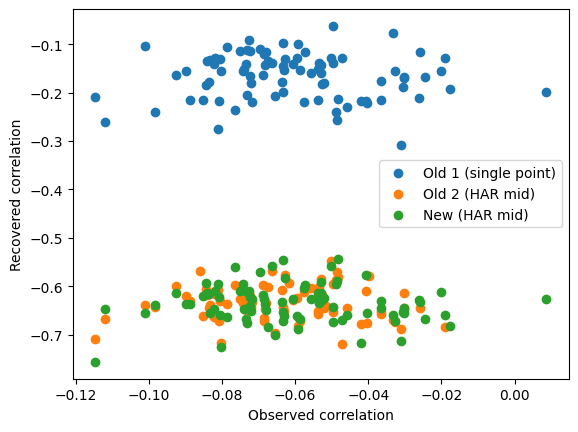

In [59]:
mask = (MF_ind_df['MIR222_status'] == "INFEASIBLE").values.squeeze()
plt.scatter(corr_df['MIR222_OB'][mask], MF_int_df_old_1['MIR222_d3_c95_correlation'][mask], label="Old 1 (single point)");
HAR_mid_old_2 = (MF_int_df_old_2['MIR222_All_d3_N1000_c95_mc95_HAR_min'] + MF_int_df_old_2['MIR222_All_d3_N1000_c95_mc95_HAR_max']) / 2
plt.scatter(corr_df['MIR222_OB'][HAR_mid_old_2.index], HAR_mid_old_2, label="Old 2 (HAR mid)");
plt.scatter(corr_df['MIR222_OB'], MF_int_df['MIR222_HAR_mid'], label="New (HAR mid)")
plt.xlabel("Observed correlation")
plt.ylabel("Recovered correlation")
plt.legend()
plt.show()

# mRNA - mRNA correlations

In [66]:
rng = np.random.default_rng(222)

## Selection

In [103]:
# choose miRNA
miRNA = "MIR222"

# select results
ind = MF_ind_df[f'{miRNA}_status']
mid = MF_int_df[f'{miRNA}_HAR_mid']

In [104]:
# size
M = 25

# get names of negatively correlated interacting pcRNA
names_neg = mid[mid < -0.25].index.tolist()
#names_neg = rng.choice(names_neg, size=M, replace=False)
names_neg = names_neg[:M]

# get names of positively correlated interacting pcRNA
#names_pos = mid[mid > 0.25].index.tolist()
#names_pos = rng.choice(names_pos, size=M, replace=False)

# get names of independent pcRNA
mask_ind = (ind == "OPTIMAL")
names_ind = mask_ind.index[mask_ind.values.squeeze()].tolist()
#names_ind = rng.choice(names_ind, size=M, replace=False)#
names_ind = names_ind[:M]

# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var.index.isin(names_neg)]
#adata_pos = adata_pcRNA[:, adata_pcRNA.var.index.isin(names_pos)]
adata_ind = adata_pcRNA[:, adata_pcRNA.var.index.isin(names_ind)]

## Correlations between each group

In [105]:
# compute correlations between all pairs of M genes: no repeats
Is, Js = np.triu_indices(M, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct datasets
data_neg = SDP_miRNA.dataset.Dataset()
#data_pos = SDP_miRNA.dataset.Dataset()
data_ind = SDP_miRNA.dataset.Dataset()

data_neg.construct_dataset_adata(adata_neg, adata_neg, beta, gene_queries)
#data_pos.construct_dataset_adata(adata_pos, adata_pos, beta, gene_queries)
data_ind.construct_dataset_adata(adata_ind, adata_ind, beta, gene_queries)

# bootstrap
data_neg.bootstrap(d=3)
#data_pos.bootstrap(d=3)
data_ind.bootstrap(d=3)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00,  5.46it/s]


In [106]:
# model free independence test
MF_ind_neg = SDP_miRNA.optimization.ModelFreeOptimization(data_neg, d=3)
#MF_ind_pos = SDP_miRNA.optimization.ModelFreeOptimization(data_pos, d=3)
MF_ind_ind = SDP_miRNA.optimization.ModelFreeOptimization(data_ind, d=3)
MF_ind_neg.analyse_dataset()
#MF_ind_pos.analyse_dataset()
MF_ind_ind.analyse_dataset()

100%|██████████| 300/300 [00:12<00:00, 23.42it/s]


In [107]:
# model free interacting H&R: should really subset queries to just interacting pairs, but small enough
MF_int_neg = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_neg, d=3)
#MF_int_pos = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_pos, d=3)
MF_int_ind = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(data_ind, d=3)
MF_int_neg.analyse_dataset()
#MF_int_pos.analyse_dataset()
MF_int_ind.analyse_dataset()

100%|██████████| 300/300 [05:28<00:00,  1.10s/it]


In [108]:
# H&R correlations
HAR_points_neg, HAR_intervals_neg = MF_int_neg.compute_dataset_correlation()
#HAR_points_pos, HAR_intervals_pos = MF_int_pos.compute_dataset_correlation()
HAR_points_ind, HAR_intervals_ind = MF_int_ind.compute_dataset_correlation()

  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:08<00:00, 36.94it/s]


In [109]:
# H&R midpoints
HAR_mid_neg = (HAR_intervals_neg[:, 0] + HAR_intervals_neg[:, 1]) / 2
#HAR_mid_pos = (HAR_intervals_pos[:, 0] + HAR_intervals_pos[:, 1]) / 2
HAR_mid_ind = (HAR_intervals_ind[:, 0] + HAR_intervals_ind[:, 1]) / 2

In [110]:
# correlation
OB_neg, AL_neg = SDP_miRNA.correlation.compute_correlations(data_neg)
#OB_pos, AL_pos = SDP_miRNA.correlation.compute_correlations(data_pos)
OB_ind, AL_ind = SDP_miRNA.correlation.compute_correlations(data_ind)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 16.40it/s]


## Plots

### Violin (interacting mRNA - mRNA)

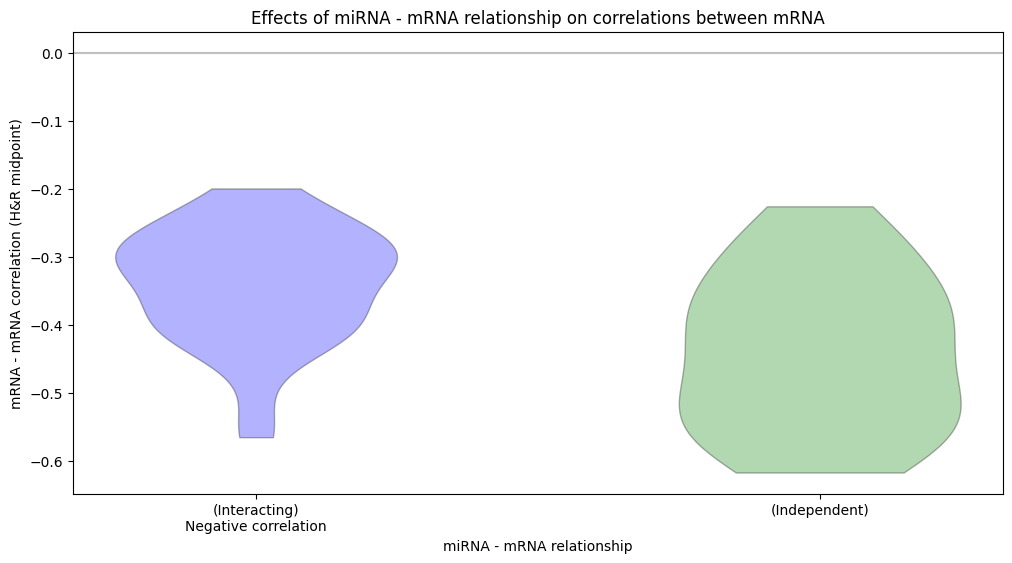

In [111]:
# remove correlations of independent pairs
ind_list = [MF_ind_neg, MF_ind_ind]
mid_list = [HAR_mid_neg, HAR_mid_ind]
plot_data_list = []
for indx, midx in zip(ind_list, mid_list):
    mask = np.array([True if sol['status'] == "INFEASIBLE" else False for sol in indx.result_dict.values()])
    midx = midx[mask]
    # also drop any nan
    midx = midx[~np.isnan(midx)]
    plot_data_list.append(midx)

# plot
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "green"]
plot_labels = ["A", "B",]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1])
axs.set_xticklabels(["(Interacting)\nNegative correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

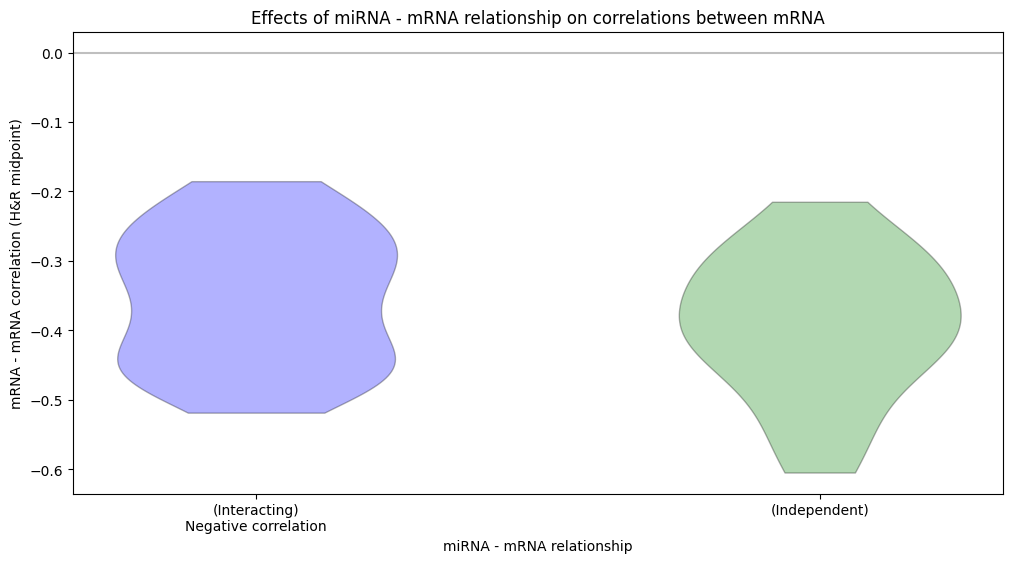

In [ ]:
# random 25

### Violin (all mRNA - mRNA)

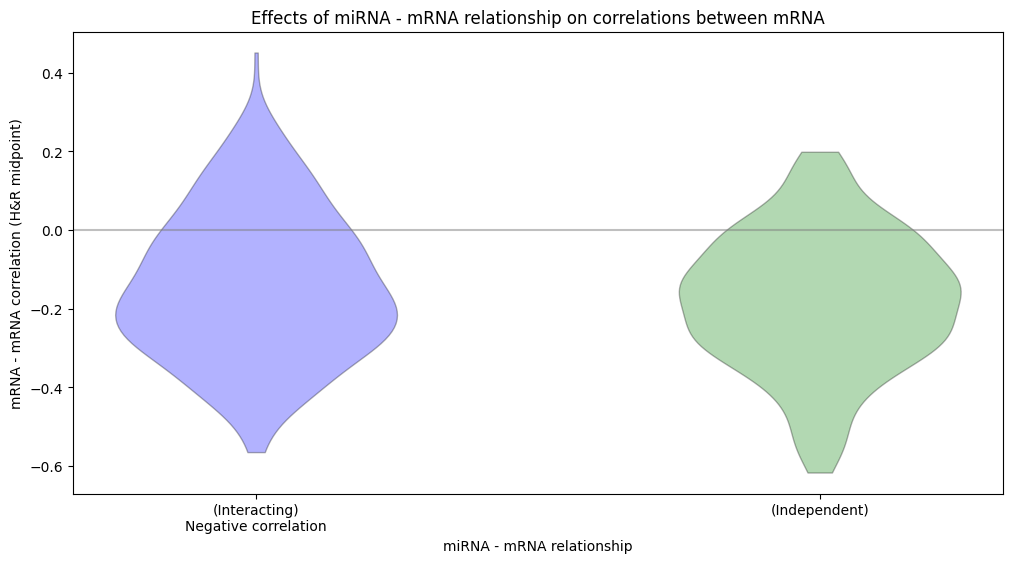

In [112]:
# remove correlations of independent pairs
ind_list = [MF_ind_neg, MF_ind_ind]
mid_list = [HAR_mid_neg, HAR_mid_ind]
plot_data_list = []
for indx, midx in zip(ind_list, mid_list):
    #mask = np.array([True if sol['status'] == "INFEASIBLE" else False for sol in indx.result_dict.values()])
    #midx = midx[mask]
    # also drop any nan
    midx = midx[~np.isnan(midx)]
    plot_data_list.append(midx)

# plot
fig, axs = plt.subplots(figsize=(12, 6))
plot_colors = ["blue", "green"]
plot_labels = ["A", "B",]
for i, plot_data in enumerate(plot_data_list):
    vp = axs.violinplot(
        dataset=plot_data,
        positions=[i],
        showextrema=False,
        side="both"
    )
    plt.setp(vp['bodies'], facecolor=plot_colors[i], edgecolor='black')
axs.axhline(0, color="grey", alpha=0.5)
axs.set_xticks([0, 1])
axs.set_xticklabels(["(Interacting)\nNegative correlation", "(Independent)"])
axs.set_xlabel("miRNA - mRNA relationship")
axs.set_ylabel("mRNA - mRNA correlation (H&R midpoint)")
axs.set_title("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.show()

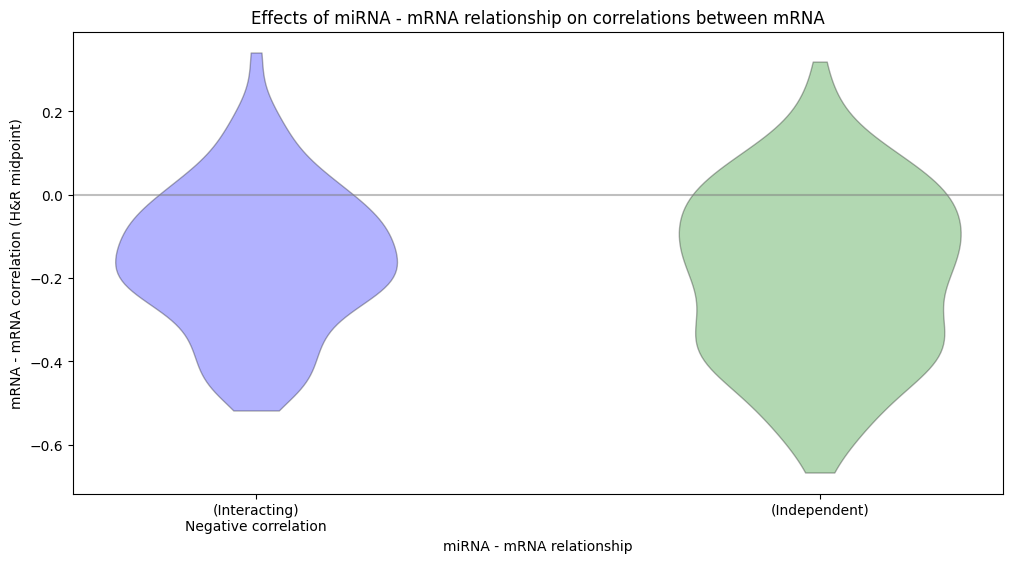

In [ ]:
# random 25

### Heatmap (interacting mRNA - mRNA)

In [113]:
from matplotlib.colors import LinearSegmentedColormap

In [114]:
corr_matrix_neg = np.zeros((M, M))
corr_matrix_ind = np.zeros((M, M))
for i, query in enumerate(data_neg.gene_queries):
    if MF_ind_neg.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_neg[query[0][0], query[1][0]] = HAR_mid_neg[i]
for i, query in enumerate(data_ind.gene_queries):
    if MF_ind_ind.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_ind[query[0][0], query[1][0]] = HAR_mid_ind[i]

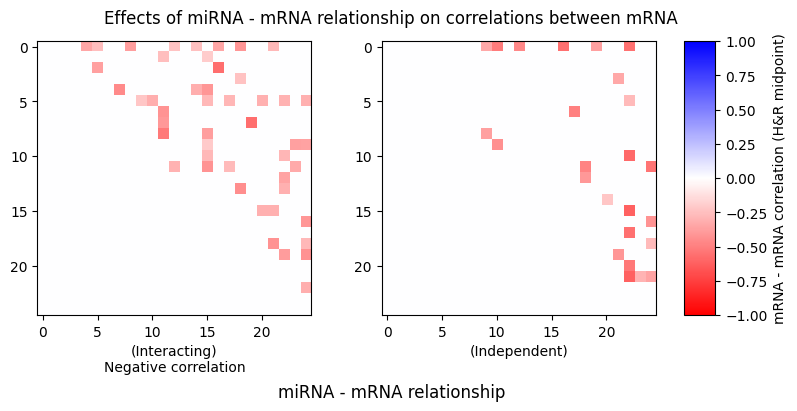

In [115]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(corr_matrix_neg, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(corr_matrix_ind, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("(Interacting)\nNegative correlation")
axs[1].set_xlabel("(Independent)")
fig.supxlabel("miRNA - mRNA relationship")
fig.suptitle("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.colorbar(im, cax=axs[2], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

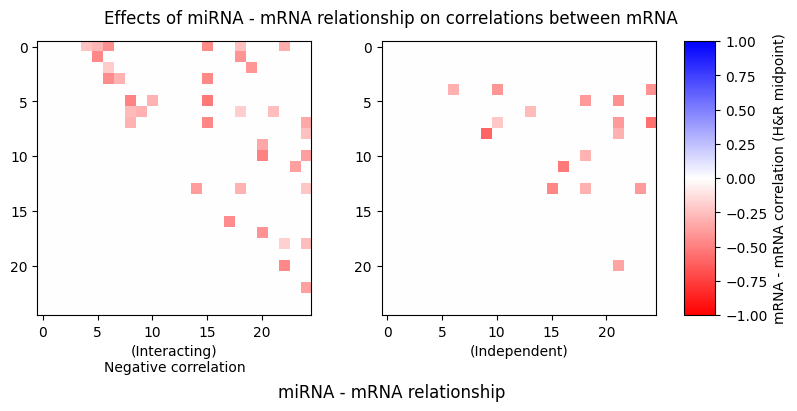

In [ ]:
# random 25

### Heatmap (all mRNA - mRNA)

In [116]:
corr_matrix_neg = np.zeros((M, M))
corr_matrix_ind = np.zeros((M, M))
for i, query in enumerate(data_neg.gene_queries):
    corr_matrix_neg[query[0][0], query[1][0]] = HAR_mid_neg[i]
for i, query in enumerate(data_ind.gene_queries):
    corr_matrix_ind[query[0][0], query[1][0]] = HAR_mid_ind[i]

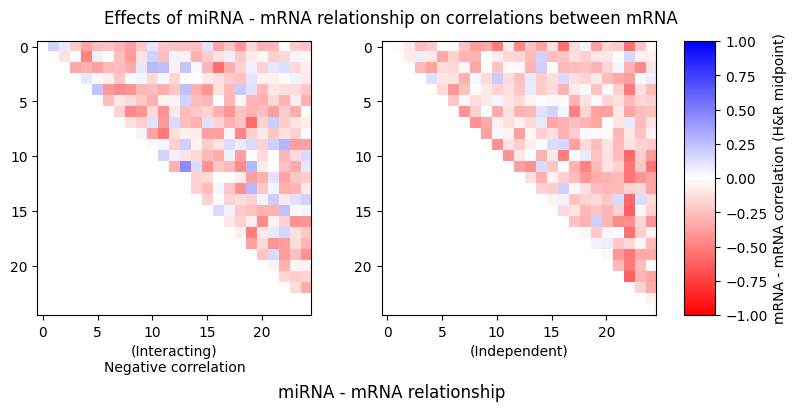

In [117]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 3, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(corr_matrix_neg, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(corr_matrix_ind, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("(Interacting)\nNegative correlation")
axs[1].set_xlabel("(Independent)")
fig.supxlabel("miRNA - mRNA relationship")
fig.suptitle("Effects of miRNA - mRNA relationship on correlations between mRNA")
plt.colorbar(im, cax=axs[2], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()

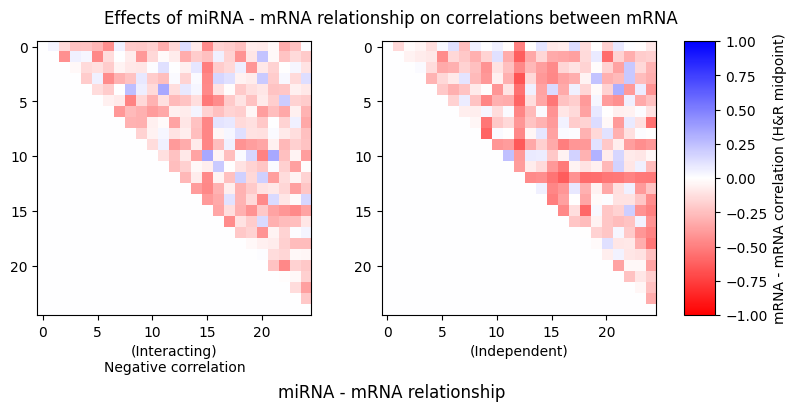

In [ ]:
# random 25

# Model Feasibility

In [120]:
# settings
d = 3

# get pcRNA names
pcRNA_names = adata_pcRNA.var.index.tolist()

# initialize result dataframes
BD_df = pd.DataFrame(index=pcRNA_names)
 
# for each miRNA
for i in range(adata_miRNA.n_vars):

    # manual selection
    i = 6

    # select miRNA
    miRNA = adata_miRNA[:, i].var.iloc[0].name

    # display progress
    print(f"{i + 1} / {adata_miRNA.n_vars}: {miRNA}")

    # select indices of interacting pairs --------------------------------------
    status = MF_ind_df[f'{miRNA}_status']
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

    # setup gene queries to these
    gene_queries = [
        [[0], [int(i)]] for i in int_idxs
    ]

    # store total
    full_query_total = status.size

    # initialize dataset -------------------------------------------------------
    data = SDP_miRNA.dataset.Dataset()

    # construct dataset with default: miRNA paired with all mRNA
    data.construct_dataset_adata(
        adata_miRNA[:, i],
        adata_pcRNA,
        beta,
        gene_queries
    )

    # bootstrap
    data.bootstrap(d=d)

    # (old) interacting birth death --------------------------------------------
    BD_int = SDP_miRNA.optimization.BirthDeathOptimization(data, d=d, time_limit=30, total_time_limit=30, K=None)
    BD_int.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in BD_int.result_dict.values()])

    # embedd results into array of all pairs
    status_all = np.empty(full_query_total) * np.nan
    status_all = status_all.astype(object)
    status_all[int_idxs] = status

    # store
    BD_df[f'{miRNA}_status'] = status_all

    # write results ------------------------------------------------------------
    BD_df.to_csv(f"Results/BD.csv") # commented out after running

    break

7 / 19: MIR222


100%|██████████| 85/85 [00:17<00:00,  4.96it/s]


In [124]:
# settings
d = 3

# get pcRNA names
pcRNA_names = adata_pcRNA.var.index.tolist()

# initialize result dataframes
TE_df = pd.DataFrame(index=pcRNA_names)
 
# for each miRNA
for i in range(adata_miRNA.n_vars):

    # manual selection
    i = 6

    # select miRNA
    miRNA = adata_miRNA[:, i].var.iloc[0].name

    # display progress
    print(f"{i + 1} / {adata_miRNA.n_vars}: {miRNA}")

    # select indices of BD infeasible pairs ------------------------------------
    status = BD_df[f'{miRNA}_status']
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

    # setup gene queries to these
    gene_queries = [
        [[0], [int(i)]] for i in int_idxs
    ]

    # store total
    full_query_total = status.size

    # initialize dataset -------------------------------------------------------
    data = SDP_miRNA.dataset.Dataset()

    # construct dataset with default: miRNA paired with all mRNA
    data.construct_dataset_adata(
        adata_miRNA[:, i],
        adata_pcRNA,
        beta,
        gene_queries
    )

    # bootstrap
    data.bootstrap(d=d)

    # (old) interacting telegraph --------------------------------------------
    TE_int = SDP_miRNA.optimization.TelegraphOptimization(data, d=d, time_limit=30, total_time_limit=30, cut_limit=1000, K=None)
    TE_int.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in TE_int.result_dict.values()])

    # embedd results into array of all pairs
    status_all = np.empty(full_query_total) * np.nan
    status_all = status_all.astype(object)
    status_all[int_idxs] = status

    # store
    TE_df[f'{miRNA}_status'] = status_all

    # write results ------------------------------------------------------------
    TE_df.to_csv(f"Results/TE.csv") # commented out after running

    break

7 / 19: MIR222


100%|██████████| 61/61 [06:45<00:00,  6.65s/it]


## Results

In [125]:
BD_df.value_counts()

MIR222_status
INFEASIBLE       61
OPTIMAL          24
Name: count, dtype: int64

In [126]:
TE_df.value_counts()

MIR222_status   
OPTIMAL             30
CUT_LIMIT           24
TOTAL_TIME_LIMIT     7
Name: count, dtype: int64

## RISC models

In [130]:
class RISCBirthDeathOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]",
            "1",
            "xs[1]",
            "xs[0] * xs[1]"
        ]
        vrs = np.array([
            [ 1,  0],
            [-1,  0],
            [ 0,  1],
            [ 0, -1],
            [ 0, -1]
        ])
        db = 2
        R = 5
        S = 2
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(3, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [131]:
# settings
d = 3

# get pcRNA names
pcRNA_names = adata_pcRNA.var.index.tolist()

# initialize result dataframes
BD_RISC_df = pd.DataFrame(index=pcRNA_names)
 
# for each miRNA
for i in range(adata_miRNA.n_vars):

    # manual selection
    i = 6

    # select miRNA
    miRNA = adata_miRNA[:, i].var.iloc[0].name

    # display progress
    print(f"{i + 1} / {adata_miRNA.n_vars}: {miRNA}")

    # select indices of interacting pairs --------------------------------------
    status = MF_ind_df[f'{miRNA}_status']
    int_idxs = np.arange(status.size)[status == "INFEASIBLE"]

    # setup gene queries to these
    gene_queries = [
        [[0], [int(i)]] for i in int_idxs
    ]

    # store total
    full_query_total = status.size

    # initialize dataset -------------------------------------------------------
    data = SDP_miRNA.dataset.Dataset()

    # construct dataset with default: miRNA paired with all mRNA
    data.construct_dataset_adata(
        adata_miRNA[:, i],
        adata_pcRNA,
        beta,
        gene_queries
    )

    # bootstrap
    data.bootstrap(d=d)

    # (old) interacting birth death --------------------------------------------
    BD_int = RISCBirthDeathOptimization(data, d=d, time_limit=30, total_time_limit=30, K=None)
    BD_int.analyse_dataset()

    # extract results
    status = np.array([sol['status'] for sol in BD_int.result_dict.values()])

    # embedd results into array of all pairs
    status_all = np.empty(full_query_total) * np.nan
    status_all = status_all.astype(object)
    status_all[int_idxs] = status

    # store
    BD_RISC_df[f'{miRNA}_status'] = status_all

    # write results ------------------------------------------------------------
    BD_RISC_df.to_csv(f"Results/BD_RISC.csv") # commented out after running

    break

7 / 19: MIR222


100%|██████████| 85/85 [01:48<00:00,  1.27s/it]


In [132]:
BD_RISC_df.value_counts()

MIR222_status
INFEASIBLE       68
OPTIMAL          12
TIME_LIMIT        3
CUT_LIMIT         2
Name: count, dtype: int64

## Comparison to mRNA - mRNA correlations

In [134]:
class PairedBirthDeathOptimization(SDP_miRNA.optimization.Optimization):

    def __init__(self, dataset, **kwargs):

        # preset settings
        constraints = SDP_miRNA.constraints.Constraint(
            moment_bounds=True,
            moment_matrices=True,
            moment_equations=True
        )
        reactions = [
            "1",
            "xs[0]",
            "1",
            "xs[1]",
            "1",
            "xs[2]",
            "xs[0] * xs[1]",
            "xs[0] * xs[2]"
        ]
        vrs = np.array([
            [ 1,  0,  0],
            [-1,  0,  0],
            [ 0,  1,  0],
            [ 0, -1,  0],
            [ 0,  0,  1],
            [ 0,  0, -1],
            [-1, -1,  0],
            [-1,  0, -1]
        ])
        db = 2
        R = 8
        S = 3
        U = []

        # default fixed rate
        if not ('rate_fixed' in kwargs.keys()):
            kwargs['rate_fixed'] = [(1, 1)]

        # initialize superclass
        super().__init__(
            dataset,
            constraints,
            reactions,
            vrs,
            db,
            R,
            S,
            U,
            **kwargs
        )

In [136]:
L = 10

Is, Js = np.triu_indices(L, k=1)
gene_queries = [
    [[0], [int(i), int(j)]] for i, j in zip(Is, Js)
]

# initialize dataset
data = SDP_miRNA.dataset.Dataset()

# construct dataset with default: miRNA paired with all mRNA
data.construct_dataset_adata(
    adata_miRNA[:, 6],
    adata_neg,
    beta,
    gene_queries
)

# bootstrap
data.bootstrap(d=d)

# paired MR0 interacting birth death
BD_paired = PairedBirthDeathOptimization(data, d=d, time_limit=30, total_time_limit=30, K=None)
BD_paired.analyse_dataset()

# extract results
status = np.array([sol['status'] for sol in BD_paired.result_dict.values()])

100%|██████████| 45/45 [08:29<00:00, 11.33s/it]


In [137]:
status

array(['INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'INFEASIBLE',
       'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'TIME_LIMIT',
       'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'INFEASIBLE',
       'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'INFEASIBLE',
       'INFEASIBLE', 'INFEASIBLE', 'OPTIMAL', 'INFEASIBLE', 'TIME_LIMIT',
       'OPTIMAL', 'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'INFEASIBLE',
       'TIME_LIMIT', 'INFEASIBLE', 'TOTAL_TIME_LIMIT', 'INFEASIBLE',
       'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'TIME_LIMIT',
       'INFEASIBLE', 'INFEASIBLE', 'INFEASIBLE', 'OPTIMAL', 'INFEASIBLE',
       'INFEASIBLE', 'TIME_LIMIT', 'INFEASIBLE', 'OPTIMAL', 'INFEASIBLE',
       'TIME_LIMIT'], dtype='<U16')

In [156]:
corr_matrix_neg = np.zeros((M, M))
feas_matrix_neg = np.ones((L, L)) * 0.5
for i, query in enumerate(data_neg.gene_queries):
    if MF_ind_neg.result_dict[i]['status'] == "INFEASIBLE":
        corr_matrix_neg[query[0][0], query[1][0]] = HAR_mid_neg[i]
for i, query in enumerate(gene_queries):
    if BD_paired.result_dict[i]['status'] == "INFEASIBLE":
        feas_matrix_neg[query[1][0], query[1][1]] = 1
    elif BD_paired.result_dict[i]['status'] == "OPTIMAL":
        feas_matrix_neg[query[1][0], query[1][1]] = 0

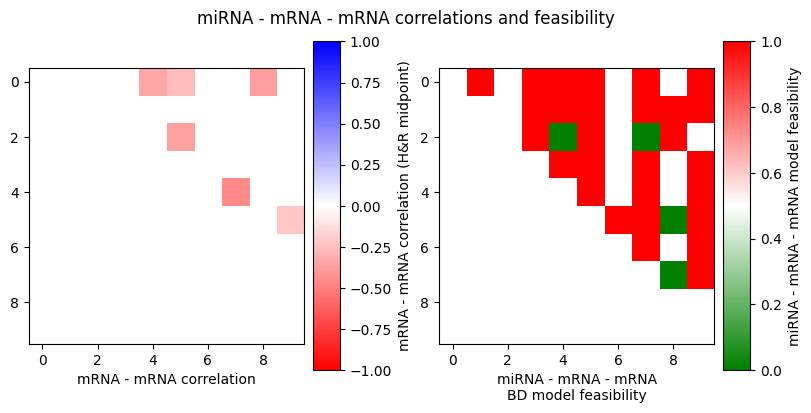

In [161]:
cmap_corr = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
cmap_feas = LinearSegmentedColormap.from_list('a', ['green', 'white', 'red'])
fig, axs = plt.subplots(1, 4, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 0.1, 1, 0.1]}, constrained_layout=True)
im_corr = axs[0].imshow(corr_matrix_neg[:L, :L], cmap=cmap_corr, vmin=-1, vmax=1)
im_feas = axs[2].imshow(feas_matrix_neg, cmap=cmap_feas, vmin=0, vmax=1)
axs[0].set_xlabel("mRNA - mRNA correlation")
axs[2].set_xlabel("miRNA - mRNA - mRNA\nBD model feasibility")
fig.suptitle("miRNA - mRNA - mRNA correlations and feasibility")
plt.colorbar(im_corr, cax=axs[1], label="mRNA - mRNA correlation (H&R midpoint)")
plt.colorbar(im_feas, cax=axs[3], label="miRNA - mRNA - mRNA model feasibility")
plt.show()

## Comparison to previous results

In [85]:
BD_df_old_1 = pd.read_csv("../../Moment-equations/Real-Data-2/Results/interacting_BD.csv", index_col=0)
BD_df_old_2 = pd.read_csv("../../Latent-Experiments/Cell-Cycle-Investigation/Results/BD_concat.csv", index_col=0)

In [90]:
#BD_df_old_1['MIR222_d333_c95_t30_c100_status'] # only have for MIR199A2

In [92]:
#BD_df_old_2 # only have for MIR199A1